# H3: Deterrence

**Hypothesis**: Lower confidence in companies' ability to detect and act on cheating will be associated with greater willingness to engage in it. When candidates believe the expected cost of cheating is low — whether because detection is unlikely or because consequences are unlikely to follow even when cheating is suspected — the deterrence mechanism that might otherwise restrain behavior is weakened.

**Relevant Survey Items:**
| Variable | Column | Question |
|---|---|---|
| `q23_detect_confidence` | Optional Question 3 | How confident are you that companies can effectively detect cheating in virtual interviews? |
| `q24_enforce_confidence` | Optional Question 4 | How confident are you that companies act on suspected cheating? |
| `q13a_willingness_high_n` | Question 13a | Willingness to cheat under high peer cheating conditions |
| `q25_consequence` | Optional Question 5 | Appropriate consequence for AI-assisted cheating |
| `q22_report_peer` | Optional Question 2 | Likelihood of reporting a peer who cheated |

**Agent data (fixed, from paper):**
- Detection confidence: 58/150 Slightly Confident, 92/150 Moderately Confident, 0 Not Confident at All, 0 Very/Extremely Confident
- Enforcement confidence: 77/150 Slightly Confident, 73/150 Moderately Confident, same extremes
- Q13a willingness: uniformly low (140 Somewhat Unlikely, 10 Extremely Unlikely)
- Q25 consequence: all 150 selected automatic disqualification
- Q22 reporting: 98% selected Extremely/Somewhat Unlikely

---

## 1. Setup and Data Loading

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})
HUMAN_COLOR  = '#2563EB'
AGENT_COLOR  = '#DC2626'
NEUTRAL_COLOR = '#6B7280'

print('Libraries loaded.')

Libraries loaded.


In [ ]:
# ── Load data ──────────────────────────────────────────────────────────────────
raw = pd.read_excel("Data Files\\Human Survey Responses.xlsx", header=0)

df = raw.iloc[1:].copy().reset_index(drop=True)

# Rename columns to short, meaningful labels using the survey map below
col_map = {
    'Consent Page'            : 'consent',
    'Question 1_1'            : 'q1_smartphone',
    'Question 1_2'            : 'q1_music',
    'Question 1_3'            : 'q1_coffee',
    'Question 1_4'            : 'q1_skydive',
    'Question 1_5'            : 'q1_helicopter',
    'Question 1_6'            : 'q1_pay_interview',
    'Question 1_7'            : 'q1_gym',
    'Question 1_8'            : 'q1_cheat_partner',
    'Question 1_9'            : 'q1_exam_cheat',
    'Question 1_10'           : 'q1_ai_interview_answers',
    'Question 1_11'           : 'q1_ai_practice',
    'Question 1_12'           : 'q1_essay_ghost',
    'Question 1_13'           : 'q1_hidden_assist',
    'Question 1_14'           : 'q1_perform_music',
    'Question 2_1'            : 'q2_pct_cheated',
    'Question 3_1'            : 'q3_ai_during',
    'Question 3_2'            : 'q3_search_engine',
    'Question 3_3'            : 'q3_questions_beforehand',
    'Question 3_4'            : 'q3_live_assist',
    'Question 3_5'            : 'q3_handwritten_notes',
    'Question 3_6'            : 'q3_ai_notes',
    'Question 4'              : 'q4_attention_color',
    'Question 5a_1'           : 'q5a_desperation',
    'Question 5a_2'           : 'q5a_competition',
    'Question 5a_3'           : 'q5a_confidence',
    'Question 5a_4'           : 'q5a_unfair_process',
    'Question 5a_5'           : 'q5a_online_risk',
    'Question 5a_6'           : 'q5a_cultural_norms',
    'Question 5a_7'           : 'q5a_lack_guidance',
    'Question 5a_8'           : 'q5a_bandwagon',
    'Question 6'              : 'q6_open_why_cheat',
    'Question 7'              : 'q7_attention_chicago_il',
    'Question 8'              : 'q8_attention_chicago_ny',
    'Question 9'              : 'q9_know_ai_hw',
    'Question 10'             : 'q10_know_ai_interview_adv',
    'Question 11'             : 'q11_know_search_live',
    'Question 12'             : 'q12_know_ai_live',
    'Q37'                     : 'code_id_raw',
    'Question 13a'            : 'q13a_willingness_high_peer',
    'Question 13b'            : 'q13b_acceptable_high_peer',
    'Question 14a'            : 'q14a_willingness_no_peer',
    'Question 14b'            : 'q14b_acceptable_no_peer',
    'Question 15'             : 'q15_year',
    'Question 16'             : 'q16_field',
    'Question 16_21_TEXT'     : 'q16_field_other',
    'Question 17'             : 'q17_industry',
    'Question 17_19_TEXT'     : 'q17_industry_other',
    'Question 18'             : 'q18_employment',
    'Question 19'             : 'q19_num_interviews',
    'Question 20'             : 'q20_interview_format',
    'Feedback Question'       : 'feedback',
    'Raffle Question'         : 'raffle',
    'Branching Question'      : 'branching',
    'Optional Question 1'     : 'q21_fairness',
    'Optional Question 2'     : 'q22_report_peer',
    'Optional Question 3'     : 'q23_detect_confidence',
    'Optional Question 4'     : 'q24_enforce_confidence',
    'Optional Question 5'     : 'q25_consequence',
    'Optional Question 6'     : 'q26_ai_skill_confidence',
    'HAVE_SYMBOL'             : 'have_symbol',
    'HAVE_NOT_SYMBOL'         : 'have_not_symbol',
    'CODE_ID'                 : 'code_id',
}
df.rename(columns=col_map, inplace=True)

print(f'Dataset: {len(df)} human respondents, {len(df.columns)} columns')
df.head(242)

Dataset: 249 human respondents, 69 columns


,UserLanguage,consent,q1_smartphone,q1_music,q1_coffee,q1_skydive,q1_helicopter,q1_pay_interview,q1_gym,q1_cheat_partner,...,q25_consequence,q26_ai_skill_confidence,have_symbol,have_not_symbol,code_id,Q_AmbiguousTextPresent,Q_AmbiguousTextQuestions,Q_StraightliningCount,Q_StraightliningPercentage,Q_StraightliningQuestions
0,EN,I agree to participate in this research study.,Very Common,Very Common,Very Common,Uncommon,Very Rare,Very Rare,NaN,Rare,...,NaN,NaN,ODD NUMBER,UPPERCASE LETTER,4,0,NaN,0,0,NaN
1,EN,I agree to participate in this research study.,Very Common,NaN,Very Common,NaN,Very Rare,Very Rare,Common,Uncommon,...,NaN,NaN,UPPERCASE LETTER,COLOR,1,0,NaN,0,0,NaN
2,EN,I agree to participate in this research study.,NaN,Very Common,Very Common,Rare,Very Rare,NaN,NaN,Uncommon,...,Automatic disqualification from the current ap...,Not confident at all,UPPERCASE LETTER,COLOR,1,0,NaN,1,0.333333,QID11
3,EN,I agree to participate in this research study.,NaN,NaN,Very Common,Uncommon,Very Rare,Rare,Common,Rare,...,Permanent ban from applying to the company.,Slightly confident,UPPERCASE LETTER,COLOR,1,0,NaN,0,0,NaN
4,EN,I agree to participate in this research study.,Very Common,Common,Very Common,Very Rare,Very Rare,NaN,Common,Very Rare,...,NaN,NaN,LOWERCASE LETTER,EVEN NUMBER,5,0,NaN,1,0.333333,QID11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,EN,I agree to participate in this research study.,NaN,Very Common,Common,NaN,Rare,Uncommon,Common,Common,...,Automatic disqualification from the current ap...,Not confident at all,COLOR,LOWERCASE LETTER,2,0,NaN,0,0,NaN
238,EN,I agree to participate in this research study.,NaN,NaN,Uncommon,NaN,Very Rare,Very Rare,Uncommon,Very Rare,...,Automatic disqualification from the current ap...,Moderately confident,COLOR,LOWERCASE LETTER,2,0,NaN,0,0,NaN
239,EN,I agree to participate in this research study.,Very Common,Very Common,Very Common,Very Rare,Very Rare,NaN,NaN,Common,...,NaN,NaN,COLOR,LOWERCASE LETTER,2,0,NaN,0,0,NaN
240,EN,I agree to participate in this research study.,NaN,NaN,Very Common,NaN,Very Rare,Rare,Very Common,Rare,...,NaN,NaN,COLOR,LOWERCASE LETTER,2,0,NaN,0,0,NaN


---
## 2. Ordinal Encoding

In [41]:
# ── Confidence scale (Q23, Q24) — higher = MORE confident ─────────────────────
confidence_map = {
    'Not confident at all': 1,
    'Slightly confident'  : 2,
    'Moderately confident': 3,
    'Very confident'      : 4,
    'Extremely confident' : 5,
}
confidence_order = list(confidence_map.keys())

# ── Willingness scale (Q13a, Q14a) — higher = MORE willing ────────────────────
willing_map = {
    'Extremely unlikely'         : 1,
    'Somewhat unlikely'          : 2,
    'Neither likely nor unlikely': 3,
    'Somewhat likely'            : 4,
    'Extremely likely'           : 5,
    'Extremely Likely'           : 5,
}
willing_order = ['Extremely unlikely','Somewhat unlikely',
                 'Neither likely nor unlikely','Somewhat likely','Extremely likely']

# ── Reporting likelihood (Q22) — higher = MORE likely to report ────────────────
report_map = {
    'Extremely unlikely'         : 1,
    'Somewhat unlikely'          : 2,
    'Neither likely nor unlikely': 3,
    'Somewhat likely'            : 4,
    'Extremely likely'           : 5,
    'Extremely Likely'           : 5,
}

# ── Consequence severity (Q25) — ordered from lightest to harshest ─────────────
consequence_order = [
    'No consequence, as it\'s part of modern technology use.',
    "Warning, no penalty.",
    'Automatic disqualification from the current application.',
    'Permanent ban from applying to the company.',
    'Industry-wide ban',
]
consequence_severity = {c: i+1 for i, c in enumerate(consequence_order)}

# Apply encodings
df['q23_detect_n']   = df['q23_detect_confidence'].map(confidence_map)
df['q24_enforce_n']  = df['q24_enforce_confidence'].map(confidence_map)
df['q13a_willing_n'] = df['q13a_willingness_high_peer'].map(willing_map)
df['q14a_willing_n'] = df['q14a_willingness_no_peer'].map(willing_map)
df['q22_report_n']   = df['q22_report_peer'].map(report_map)
df['q25_severity_n'] = df['q25_consequence'].map(consequence_severity)

# Composite deterrence skepticism: mean of detect + enforce (lower = more skeptical)
df['deterrence_skepticism'] = df[['q23_detect_n','q24_enforce_n']].mean(axis=1)

# "Not confident at all" flag on either item — referenced in paper
df['any_not_confident'] = (
    (df['q23_detect_confidence'] == 'Not confident at all') |
    (df['q24_enforce_confidence'] == 'Not confident at all')
)

# "Willing to cheat" flag: Somewhat or Extremely Likely on Q13a
df['willing_flag'] = df['q13a_willingness_high_peer'].isin(
    ['Somewhat likely','Extremely likely','Extremely likely']
)

# Light consequence flag: No penalty or warning
df['light_consequence'] = df['q25_consequence'].isin(
    ["Warning, no penalty.", 'No consequence, as it\'s part of modern technology use.']
)

print('Encoding complete.')
df[['q23_detect_confidence','q23_detect_n',
    'q24_enforce_confidence','q24_enforce_n',
    'q13a_willingness_high_peer','q13a_willing_n',
    'q14a_willingness_no_peer','q14a_willing_n',
    'q25_consequence','q25_severity_n']].head(242)

Encoding complete.


,q23_detect_confidence,q23_detect_n,q24_enforce_confidence,q24_enforce_n,q13a_willingness_high_peer,q13a_willing_n,q14a_willingness_no_peer,q14a_willing_n,q25_consequence,q25_severity_n
0,NaN,NaN,NaN,NaN,Extremely likely,5,Neither likely nor unlikely,3,NaN,NaN
1,NaN,NaN,NaN,NaN,Extremely likely,5,Neither likely nor unlikely,3,NaN,NaN
2,Not confident at all,1.0,Slightly confident,2.0,Somewhat likely,4,Neither likely nor unlikely,3,Automatic disqualification from the current ap...,3.0
3,Moderately confident,3.0,Moderately confident,3.0,Somewhat likely,4,Extremely unlikely,1,Permanent ban from applying to the company.,4.0
4,NaN,NaN,NaN,NaN,Extremely unlikely,1,Extremely unlikely,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
237,Not confident at all,1.0,Not confident at all,1.0,Extremely unlikely,1,Extremely unlikely,1,Automatic disqualification from the current ap...,3.0
238,Moderately confident,3.0,Moderately confident,3.0,Somewhat likely,4,Extremely unlikely,1,Automatic disqualification from the current ap...,3.0
239,NaN,NaN,NaN,NaN,Extremely likely,5,Somewhat likely,4,NaN,NaN
240,NaN,NaN,NaN,NaN,Neither likely nor unlikely,3,Extremely unlikely,1,NaN,NaN


---
## 3. Detection Confidence Distribution (Q23)

> *"No human respondent and no agent reported being 'Very Confident' or 'Extremely Confident' in companies' ability to detect cheating... Human respondents showed a similar central tendency but with greater dispersion: [X]% reported 'Slightly Confident' and [X]% 'Moderately Confident' on detection, while [X]% reported 'Not Confident at All'..."*

In [ ]:
# ── Fill-in computations ───────────────────────────────────────────────────────
q23_valid  = df['q23_detect_confidence'].dropna()
q23_counts = q23_valid.value_counts().reindex(confidence_order, fill_value=0)
q23_pct    = (q23_counts / len(q23_valid) * 100).round(1) if len(q23_valid) > 0 else q23_counts * 0

q24_valid  = df['q24_enforce_confidence'].dropna()
q24_counts = q24_valid.value_counts().reindex(confidence_order, fill_value=0)
q24_pct    = (q24_counts / len(q24_valid) * 100).round(1) if len(q24_valid) > 0 else q24_counts * 0

print('── Q23: Detection Confidence (Human Respondents) ──')
for lbl in confidence_order:
    print(f'  {lbl:<25}: n={q23_counts[lbl]:>3}  ({q23_pct[lbl]:.1f}%)')
print(f'  Total with response : {len(q23_valid)}')

print('\n── Q24: Enforcement Confidence (Human Respondents) ──')
for lbl in confidence_order:
    print(f'  {lbl:<25}: n={q24_counts[lbl]:>3}  ({q24_pct[lbl]:.1f}%)')
print(f'  Total with response : {len(q24_valid)}')

print(f"  Q23 Slightly Confident    : {q23_pct.get('Slightly confident', 0):.1f}%")
print(f"  Q23 Moderately Confident  : {q23_pct.get('Moderately confident', 0):.1f}%")
print(f"  Q23 Not Confident at All  : {q23_pct.get('Not confident at all', 0):.1f}%")
not_conf_either = df['any_not_confident'].sum()
n_opt = df['q23_detect_confidence'].notna().sum()
print(f"  Not Confident at All on either Q23/Q24: n={not_conf_either} ({not_conf_either/n_opt*100:.1f}% of optional completers)" if n_opt > 0 else '  Not Confident at All: [no data yet]')

── Q23: Detection Confidence (Human Respondents) ──
  Not confident at all     : n= 61  (44.5%)
  Slightly confident       : n= 49  (35.8%)
  Moderately confident     : n= 24  (17.5%)
  Very confident           : n=  2  (1.5%)
  Extremely confident      : n=  1  (0.7%)
  Total with response : 137

── Q24: Enforcement Confidence (Human Respondents) ──
  Not confident at all     : n= 42  (30.7%)
  Slightly confident       : n= 45  (32.8%)
  Moderately confident     : n= 31  (22.6%)
  Very confident           : n= 18  (13.1%)
  Extremely confident      : n=  1  (0.7%)
  Total with response : 137

── [X] FILL-IN VALUES FOR LATEX ──
  Q23 Slightly Confident    : 35.8%
  Q23 Moderately Confident  : 17.5%
  Q23 Not Confident at All  : 44.5%
  Not Confident at All on either Q23/Q24: n=71 (51.8% of optional completers)


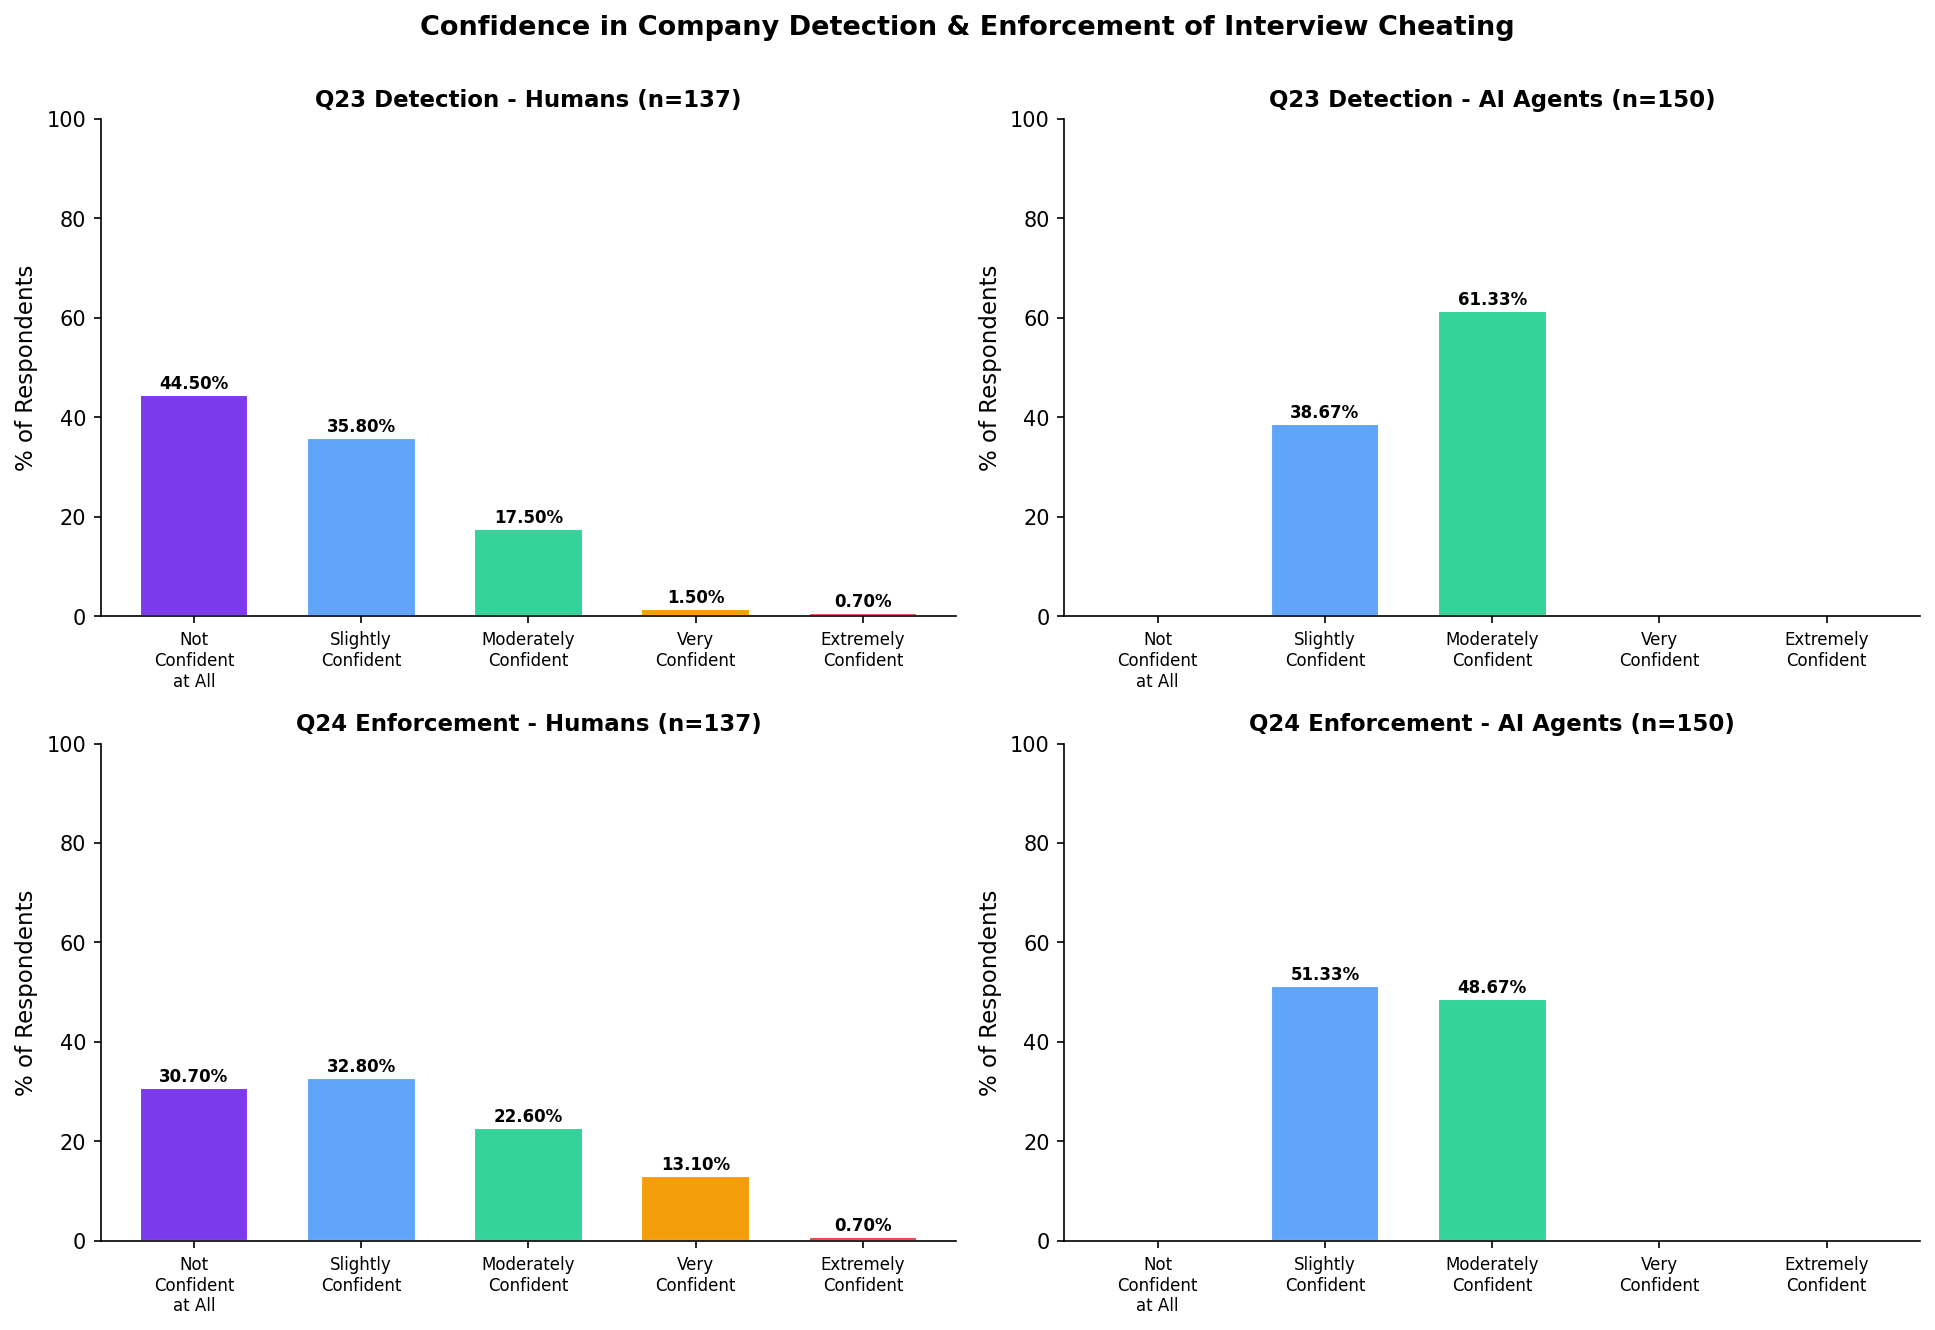

Saved: fig_h3_confidence_distributions.png


In [43]:
# ── Figure 1: Detection & Enforcement Confidence — Human vs Agent ──────────────
# Agent data (fixed from paper)
agent_detect  = pd.Series({'Not confident at all':0,'Slightly confident':58,
                            'Moderately confident':92,'Very confident':0,'Extremely confident':0})
agent_enforce = pd.Series({'Not confident at all':0,'Slightly confident':77,
                            'Moderately confident':73,'Very confident':0,'Extremely confident':0})
agent_detect_pct  = (agent_detect  / 150 * 100)
agent_enforce_pct = (agent_enforce / 150 * 100)

conf_colors = ['#7C3AED','#60A5FA','#34D399','#F59E0B','#EF4444']
x = np.arange(len(confidence_order))
short_labels = ['Not\nConfident\nat All','Slightly\nConfident',
                'Moderately\nConfident','Very\nConfident','Extremely\nConfident']

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=False)
datasets = [
    (axes[0,0], q23_pct,           f'Q23 Detection - Humans (n={len(q23_valid)})',  HUMAN_COLOR),
    (axes[0,1], agent_detect_pct,  'Q23 Detection - AI Agents (n=150)',              AGENT_COLOR),
    (axes[1,0], q24_pct,           f'Q24 Enforcement - Humans (n={len(q24_valid)})', HUMAN_COLOR),
    (axes[1,1], agent_enforce_pct, 'Q24 Enforcement - AI Agents (n=150)',             AGENT_COLOR),
]

for ax, data, title, color in datasets:
    bars = ax.bar(x, data.reindex(confidence_order, fill_value=0).values,
                  color=conf_colors, width=0.65, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=8)
    ax.set_ylabel('% of Respondents')
    ax.set_title(title, fontweight='bold', fontsize=11)
    max_v = max(data.values) if max(data.values) > 0 else 10
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, data.reindex(confidence_order, fill_value=0).values):
        if val > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{val:.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Confidence in Company Detection & Enforcement of Interview Cheating\n', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h3_confidence_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h3_confidence_distributions.png')

---
## 4. Cross-Tab: Detection Confidence × Willingness to Cheat (Q23 × Q13a)

> *"Human respondents who reported being 'Not Confident at All' in companies' detection abilities were [X] times more likely to report being 'Somewhat Likely' or 'Extremely Likely' to cheat under high peer cheating conditions than those who reported 'Moderately Confident.'"*

In [ ]:
# ── Fill-in computations ───────────────────────────────────────────────────────
# Only optional-section completers have Q23/Q24
df_opt = df.dropna(subset=['q23_detect_n']).copy()

print(f'Optional-section completers (have Q23): n={len(df_opt)}')
print(f'Of those, also have Q13a willingness  : n={df_opt["q13a_willing_n"].notna().sum()}')
print()

# Willing rate by detection confidence group
if len(df_opt) > 0 and df_opt['q13a_willing_n'].notna().sum() > 0:
    grouped = df_opt.groupby('q23_detect_confidence')['willing_flag'].agg(['sum','count','mean'])
    grouped.columns = ['n_willing','n_total','pct_willing']
    grouped['pct_willing_pct'] = (grouped['pct_willing']*100).round(1)
    grouped = grouped.reindex([c for c in confidence_order if c in grouped.index])
    print('── Willingness rate by Q23 detection confidence ──')
    print(grouped.to_string())

    # Compute the [X] times more likely figure
    not_conf_willing = df_opt.loc[df_opt['q23_detect_confidence']=='Not confident at all','willing_flag'].mean()
    mod_conf_willing  = df_opt.loc[df_opt['q23_detect_confidence']=='Moderately confident','willing_flag'].mean()
    ratio = not_conf_willing / mod_conf_willing if mod_conf_willing and mod_conf_willing > 0 else np.nan

    print(f'  Not Confident at All → willing rate : {not_conf_willing*100:.1f}%')
    print(f'  Moderately Confident → willing rate : {mod_conf_willing*100:.1f}%')
    print(f'  Relative likelihood ratio           : {ratio:.2f}x' if not np.isnan(ratio)
          else '  Ratio: [insufficient data in both groups]')

    # Spearman correlation: lower confidence → higher willingness (expect negative r)
    analysis = df_opt.dropna(subset=['q23_detect_n','q13a_willing_n'])
    if len(analysis) >= 3:
        rho, pval = stats.spearmanr(analysis['q23_detect_n'], analysis['q13a_willing_n'])
        print(f'\n  Spearman r (detect confidence vs willingness): r={rho:.3f}, p={pval:.3f}')
        print(f'  (Negative r expected: less confident → more willing)')
    else:
        print(f'\n  Spearman r: only {len(analysis)} obs — will compute with full sample.')
else:
    print('No optional-section data yet — all [X] values will populate once data is collected.')

Optional-section completers (have Q23): n=137
Of those, also have Q13a willingness  : n=137

── Willingness rate by Q23 detection confidence ──
                       n_willing  n_total  pct_willing  pct_willing_pct
q23_detect_confidence                                                  
Not confident at all          31       61     0.508197             50.8
Slightly confident            31       49     0.632653             63.3
Moderately confident          12       24     0.500000             50.0
Very confident                 1        2     0.500000             50.0
Extremely confident            0        1     0.000000              0.0

── [X] FILL-IN VALUES FOR LATEX ──
  Not Confident at All → willing rate : 50.8%
  Moderately Confident → willing rate : 50.0%
  Relative likelihood ratio           : 1.02x

  Spearman r (detect confidence vs willingness): r=0.054, p=0.528
  (Negative r expected: less confident → more willing)


In [ ]:
# ── Fill-in computations: Q23 detection confidence × Q14a no-peer willingness ──
df_opt = df_opt.copy()
df_opt['q14a_willing_flag'] = df_opt['q14a_willingness_no_peer'].isin(
    ['Somewhat likely', 'Extremely likely', 'Extremely Likely']
)

print(f'Optional-section completers (have Q23): n={len(df_opt)}')
print(f'Of those, also have Q14a willingness : n={df_opt["q14a_willing_n"].notna().sum()}')
print()

if len(df_opt) > 0 and df_opt['q14a_willing_n'].notna().sum() > 0:
    grouped14a = df_opt.groupby('q23_detect_confidence')['q14a_willing_flag'].agg(['sum','count','mean'])
    grouped14a.columns = ['n_willing','n_total','pct_willing']
    grouped14a['pct_willing_pct'] = (grouped14a['pct_willing'] * 100).round(1)
    grouped14a = grouped14a.reindex([c for c in confidence_order if c in grouped14a.index])

    print('── Willingness rate by Q23 detection confidence (Q14a no-peer) ──')
    print(grouped14a.to_string())

    not_conf_willing_14a = df_opt.loc[
        df_opt['q23_detect_confidence'] == 'Not confident at all', 'q14a_willing_flag'
    ].mean()
    mod_conf_willing_14a = df_opt.loc[
        df_opt['q23_detect_confidence'] == 'Moderately confident', 'q14a_willing_flag'
    ].mean()
    ratio14a = not_conf_willing_14a / mod_conf_willing_14a if mod_conf_willing_14a and mod_conf_willing_14a > 0 else np.nan

    print(f'  Not Confident at All → Q14a willing rate : {not_conf_willing_14a*100:.1f}%')
    print(f'  Moderately Confident → Q14a willing rate : {mod_conf_willing_14a*100:.1f}%')
    print(f'  Relative likelihood ratio               : {ratio14a:.2f}x' if not np.isnan(ratio14a)
          else '  Ratio: [insufficient data in both groups]')

    analysis14a = df_opt.dropna(subset=['q23_detect_n','q14a_willing_n'])
    if len(analysis14a) >= 3:
        rho14a, pval14a = stats.spearmanr(analysis14a['q23_detect_n'], analysis14a['q14a_willing_n'])
        print(f'\n  Spearman r (detect confidence vs Q14a willingness): r={rho14a:.3f}, p={pval14a:.3f}')
        print('  (Negative r expected: less confident → more willing)')
    else:
        print(f'\n  Spearman r: only {len(analysis14a)} obs — will compute with full sample.')
else:
    print('No optional-section data yet — all [X] values will populate once data is collected.')

Optional-section completers (have Q23): n=137
Of those, also have Q14a willingness : n=137

── Willingness rate by Q23 detection confidence (Q14a no-peer) ──
                       n_willing  n_total  pct_willing  pct_willing_pct
q23_detect_confidence                                                  
Not confident at all           4       61     0.065574              6.6
Slightly confident             3       49     0.061224              6.1
Moderately confident           1       24     0.041667              4.2
Very confident                 0        2     0.000000              0.0
Extremely confident            0        1     0.000000              0.0

── [X] FILL-IN VALUES FOR LATEX ──
  Not Confident at All → Q14a willing rate : 6.6%
  Moderately Confident → Q14a willing rate : 4.2%
  Relative likelihood ratio               : 1.57x

  Spearman r (detect confidence vs Q14a willingness): r=-0.005, p=0.956
  (Negative r expected: less confident → more willing)


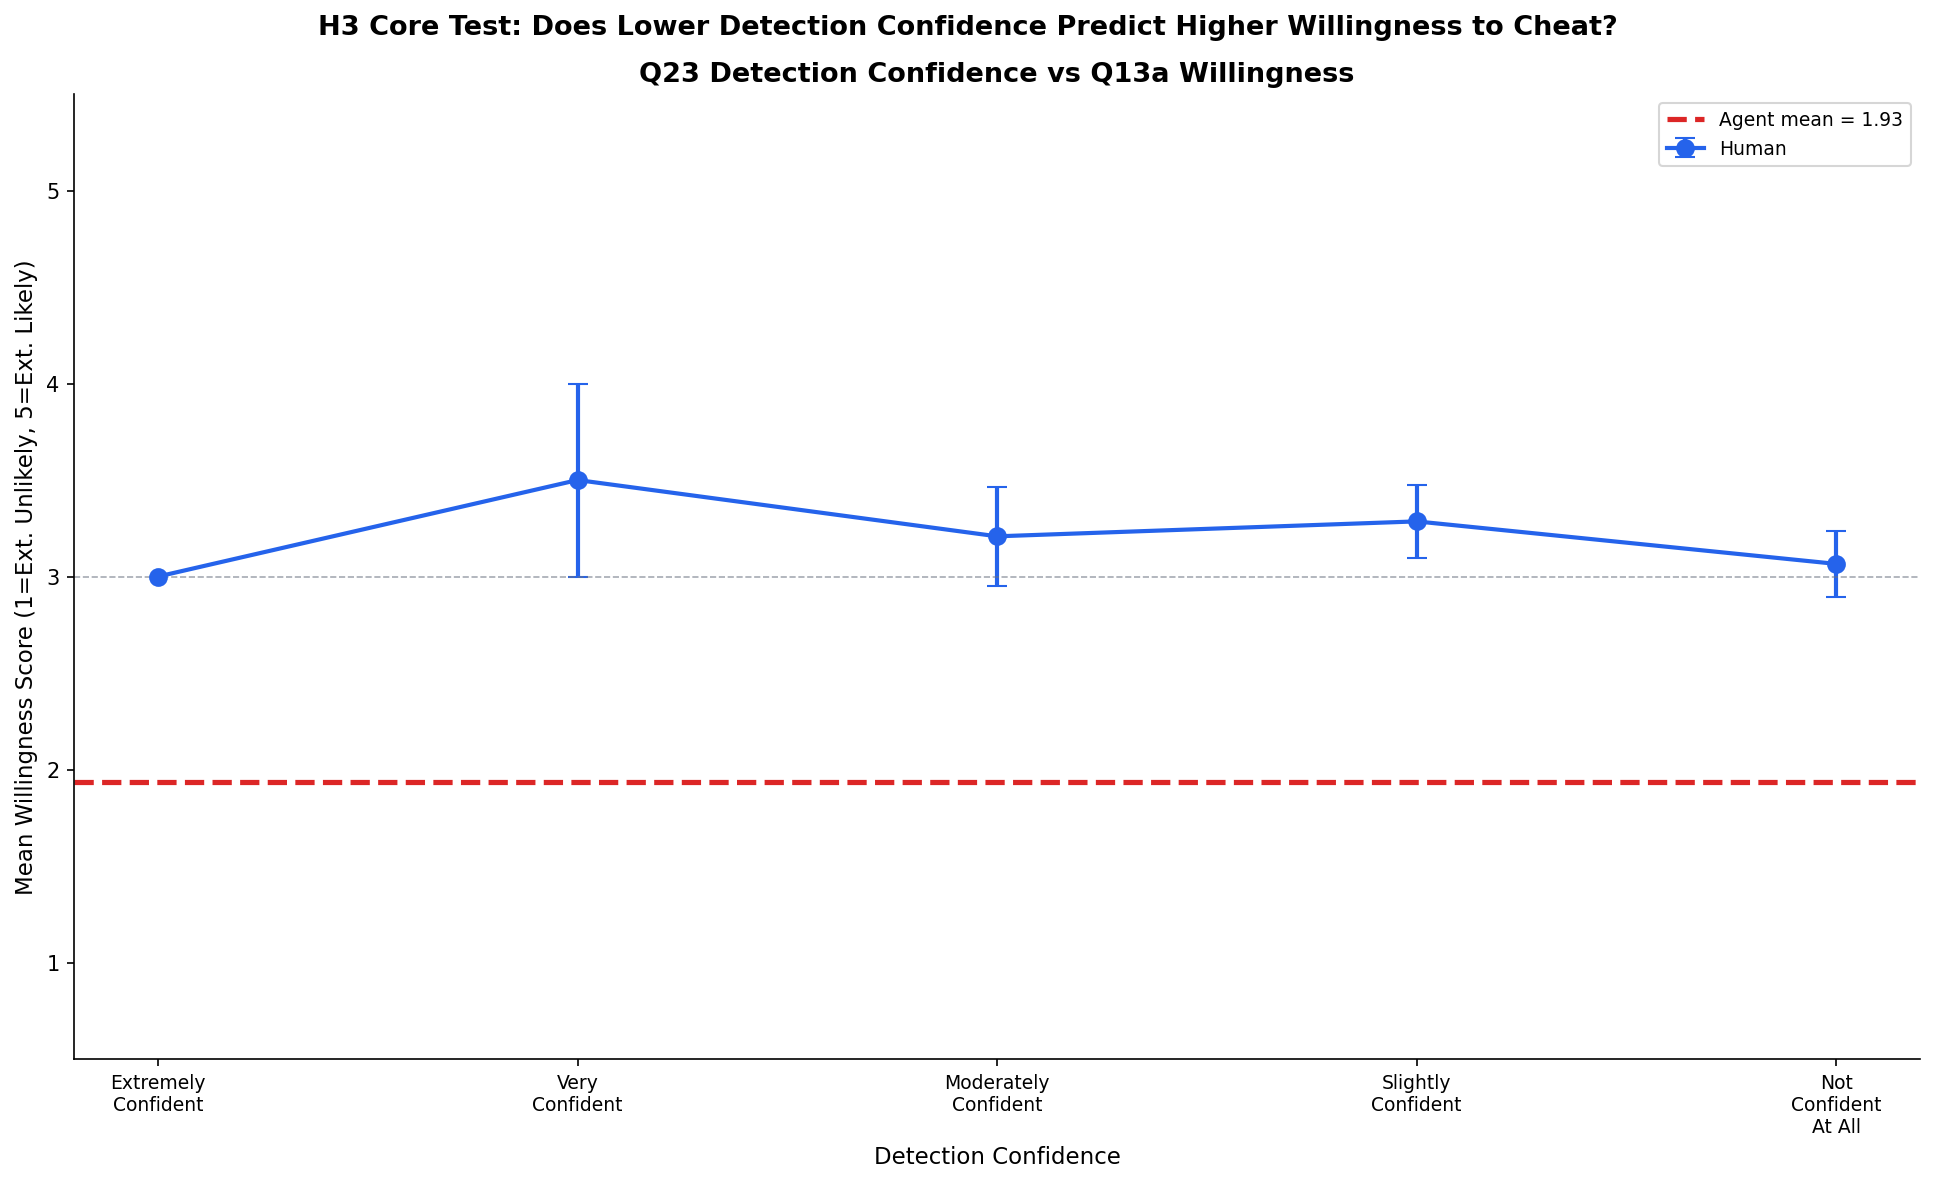

Saved: fig_h3_confidence_vs_willingness.png


In [46]:
# ── Figure 2: Willingness rate by detection confidence group ───────────────────
fig, ax = plt.subplots(figsize=(13,8))

agent_willing_mean = (140*2 + 10*1) / 150

if len(df_opt) > 0 and df_opt['q13a_willing_n'].notna().sum() > 0:
    means = df_opt.groupby('q23_detect_n')['q13a_willing_n'].mean()
    sems  = df_opt.groupby('q23_detect_n')['q13a_willing_n'].sem()

    ax.errorbar(means.index, means.values, yerr=sems.values,
                marker='o', linewidth=2, color=HUMAN_COLOR,
                capsize=5, markersize=8, label='Human')
    ax.axhline(agent_willing_mean, color=AGENT_COLOR, linestyle='--',
               linewidth=2.5, label=f'Agent mean = {agent_willing_mean:.2f}')
    #ax.fill_between([0.5, 5.5], agent_willing_mean-0.05, agent_willing_mean+0.05,
    #                color=AGENT_COLOR, alpha=0.15)

    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['Not\nConfident\nAt All', 'Slightly\nConfident', 'Moderately\nConfident', 'Very\nConfident', 'Extremely\nConfident'], fontsize=9)
    ax.set_ylabel('Mean Willingness Score (1=Ext. Unlikely, 5=Ext. Likely)')
    ax.set_ylim(0.5, 5.5)
    ax.set_title('Q23 Detection Confidence vs Q13a Willingness', fontweight='bold')
    ax.axhline(3, linestyle='--', color=NEUTRAL_COLOR, linewidth=0.8, alpha=0.6)
    ax.invert_xaxis()
    ax.set_xlabel('Detection Confidence')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'Awaiting data\n(optional section)', ha='center', va='center',
            transform=ax.transAxes, fontsize=13, color=NEUTRAL_COLOR)
    ax.set_title('Q23 Detection Confidence vs Q13a Willingness', fontweight='bold')
    ax.set_xticks([])

plt.suptitle('H3 Core Test: Does Lower Detection Confidence Predict Higher Willingness to Cheat?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h3_confidence_vs_willingness.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h3_confidence_vs_willingness.png')


---
## 5. Enforcement Confidence × Willingness (Q24 × Q13a)

Mirrors the detection analysis but for the enforcement dimension — whether companies *act* on suspected cheating.

In [47]:
# ── Fill-in computations ───────────────────────────────────────────────────────
print('── Willingness rate by Q24 enforcement confidence ──')
if len(df_opt) > 0 and df_opt['q13a_willing_n'].notna().sum() > 0:
    grouped24 = df_opt.groupby('q24_enforce_confidence')['willing_flag'].agg(['sum','count','mean'])
    grouped24.columns = ['n_willing','n_total','pct_willing']
    grouped24['pct_willing_pct'] = (grouped24['pct_willing']*100).round(1)
    grouped24 = grouped24.reindex([c for c in confidence_order if c in grouped24.index])
    print(grouped24.to_string())

    analysis24 = df_opt.dropna(subset=['q24_enforce_n','q13a_willing_n'])
    if len(analysis24) >= 3:
        rho24, pval24 = stats.spearmanr(analysis24['q24_enforce_n'], analysis24['q13a_willing_n'])
        print(f'\n  Spearman r (enforce confidence vs willingness): r={rho24:.3f}, p={pval24:.3f}')
    else:
        print(f'\n  Spearman r: {len(analysis24)} obs — will compute with full sample.')

    # Also test composite deterrence score
    analysis_comp = df_opt.dropna(subset=['deterrence_skepticism','q13a_willing_n'])
    if len(analysis_comp) >= 3:
        rho_comp, pval_comp = stats.spearmanr(
            analysis_comp['deterrence_skepticism'], analysis_comp['q13a_willing_n'])
        print(f'  Spearman r (composite deterrence vs willingness): r={rho_comp:.3f}, p={pval_comp:.3f}')
else:
    print('  No optional-section data yet.')

── Willingness rate by Q24 enforcement confidence ──
                        n_willing  n_total  pct_willing  pct_willing_pct
q24_enforce_confidence                                                  
Not confident at all           19       42     0.452381             45.2
Slightly confident             26       45     0.577778             57.8
Moderately confident           19       31     0.612903             61.3
Very confident                 11       18     0.611111             61.1
Extremely confident             0        1     0.000000              0.0

  Spearman r (enforce confidence vs willingness): r=0.087, p=0.311
  Spearman r (composite deterrence vs willingness): r=0.087, p=0.310


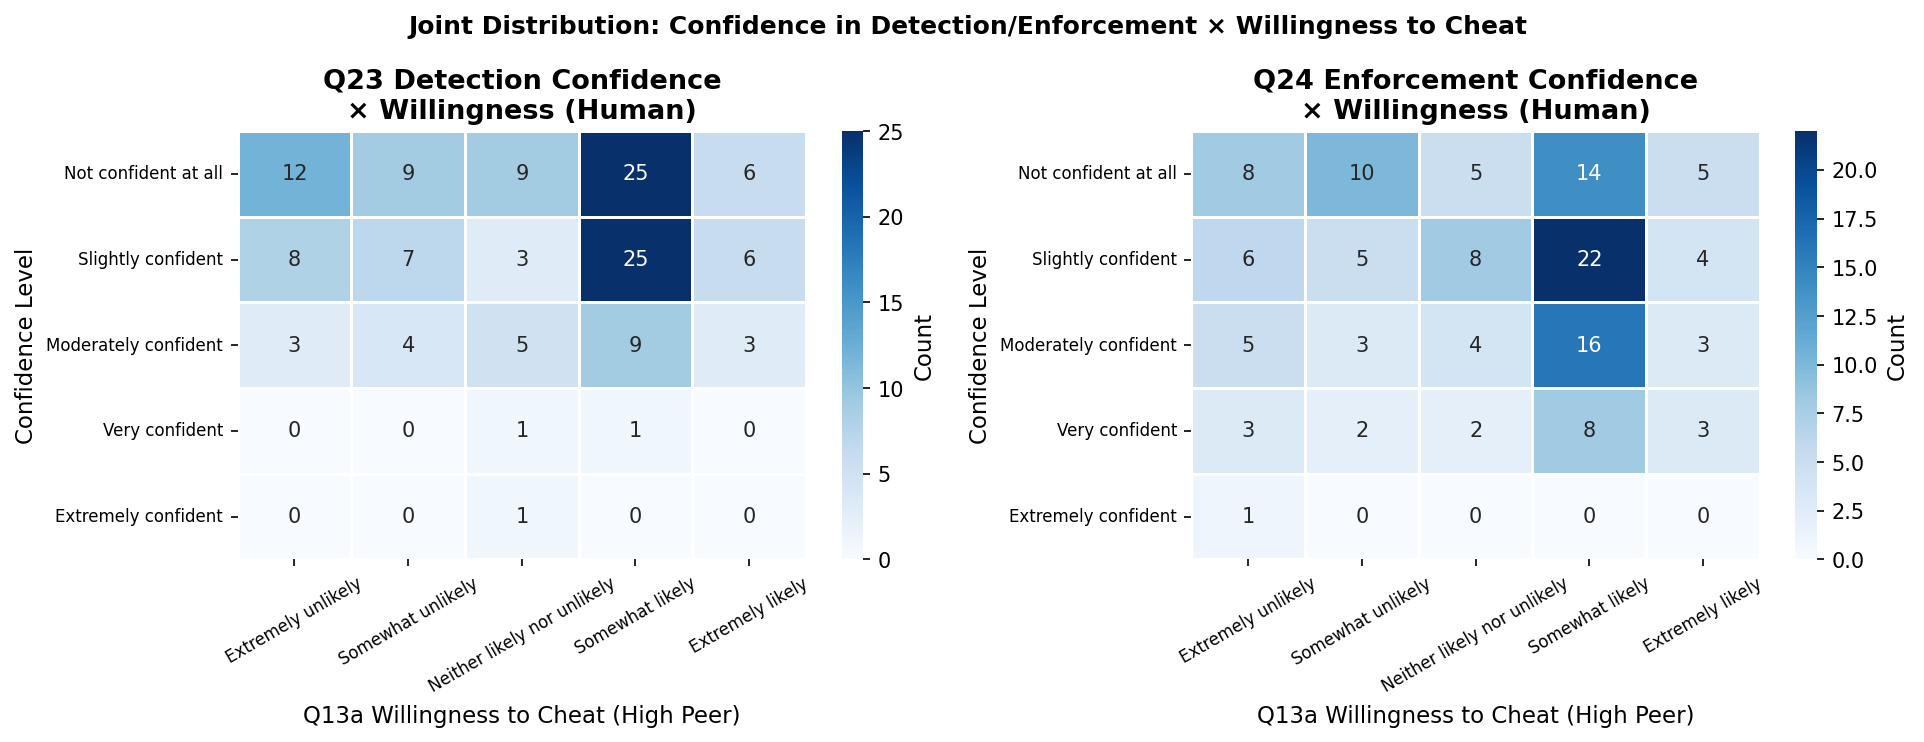

Saved: fig_h3_crosstab_heatmap.png


In [48]:
# ── Figure 3: Side-by-side heatmap — confidence level × willingness level ──────
# Shows the joint distribution of detection confidence and willingness
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, conf_col, conf_n_col, title in [
        (axes[0], 'q23_detect_confidence',  'q23_detect_n',  'Q23 Detection'),
        (axes[1], 'q24_enforce_confidence', 'q24_enforce_n', 'Q24 Enforcement'),
]:
    sub = df_opt.dropna(subset=[conf_col, 'q13a_willingness_high_peer'])
    if len(sub) >= 2:
        ct = pd.crosstab(sub[conf_col], sub['q13a_willingness_high_peer'])
        ct = ct.reindex([c for c in confidence_order if c in ct.index])
        ct = ct.reindex(columns=[w for w in willing_order if w in ct.columns])
        ct = ct.fillna(0)
        sns.heatmap(ct, annot=True, fmt='g', cmap='Blues', ax=ax,
                    cbar_kws={'label': 'Count'}, linewidths=0.5)
        ax.set_xlabel('Q13a Willingness to Cheat (High Peer)')
        ax.set_ylabel('Confidence Level')
        ax.set_title(f'{title} Confidence\n× Willingness (Human)', fontweight='bold')
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.tick_params(axis='y', rotation=0, labelsize=8)
    else:
        ax.text(0.5, 0.5, 'Awaiting data\n(optional section)', ha='center', va='center',
                transform=ax.transAxes, fontsize=13, color=NEUTRAL_COLOR)
        ax.set_title(f'{title} Confidence × Willingness', fontweight='bold')

plt.suptitle('Joint Distribution: Confidence in Detection/Enforcement × Willingness to Cheat',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h3_crosstab_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h3_crosstab_heatmap.png')

---
## 6. Consequence Preferences (Q25)

> *"Among agents, all 150 selected automatic disqualification... Human respondents showed considerably more variation. While automatic disqualification remained the modal response, [X]% called for a permanent ban... [X]% for an industry-wide ban. At the same time, [X]% called for lighter consequences including no penalty..."*

In [49]:
# ── Fill-in computations ───────────────────────────────────────────────────────
q25_valid  = df['q25_consequence'].dropna()
q25_counts = q25_valid.value_counts().reindex(consequence_order, fill_value=0)
q25_pct    = (q25_counts / len(q25_valid) * 100).round(1) if len(q25_valid) > 0 else q25_counts * 0

print('── Q25: Consequence Preferences (Human Respondents) ──')
for lbl in consequence_order:
    print(f'  {lbl:<55}: n={q25_counts[lbl]:>3}  ({q25_pct[lbl]:.2f}%)')
print(f'  Total with response : {len(q25_valid)}')


── Q25: Consequence Preferences (Human Respondents) ──
  No consequence, as it's part of modern technology use. : n=  6  (4.40%)
  Warning, no penalty.                                   : n=  9  (6.60%)
  Automatic disqualification from the current application.: n=101  (73.70%)
  Permanent ban from applying to the company.            : n= 16  (11.70%)
  Industry-wide ban                                      : n=  5  (3.60%)
  Total with response : 137


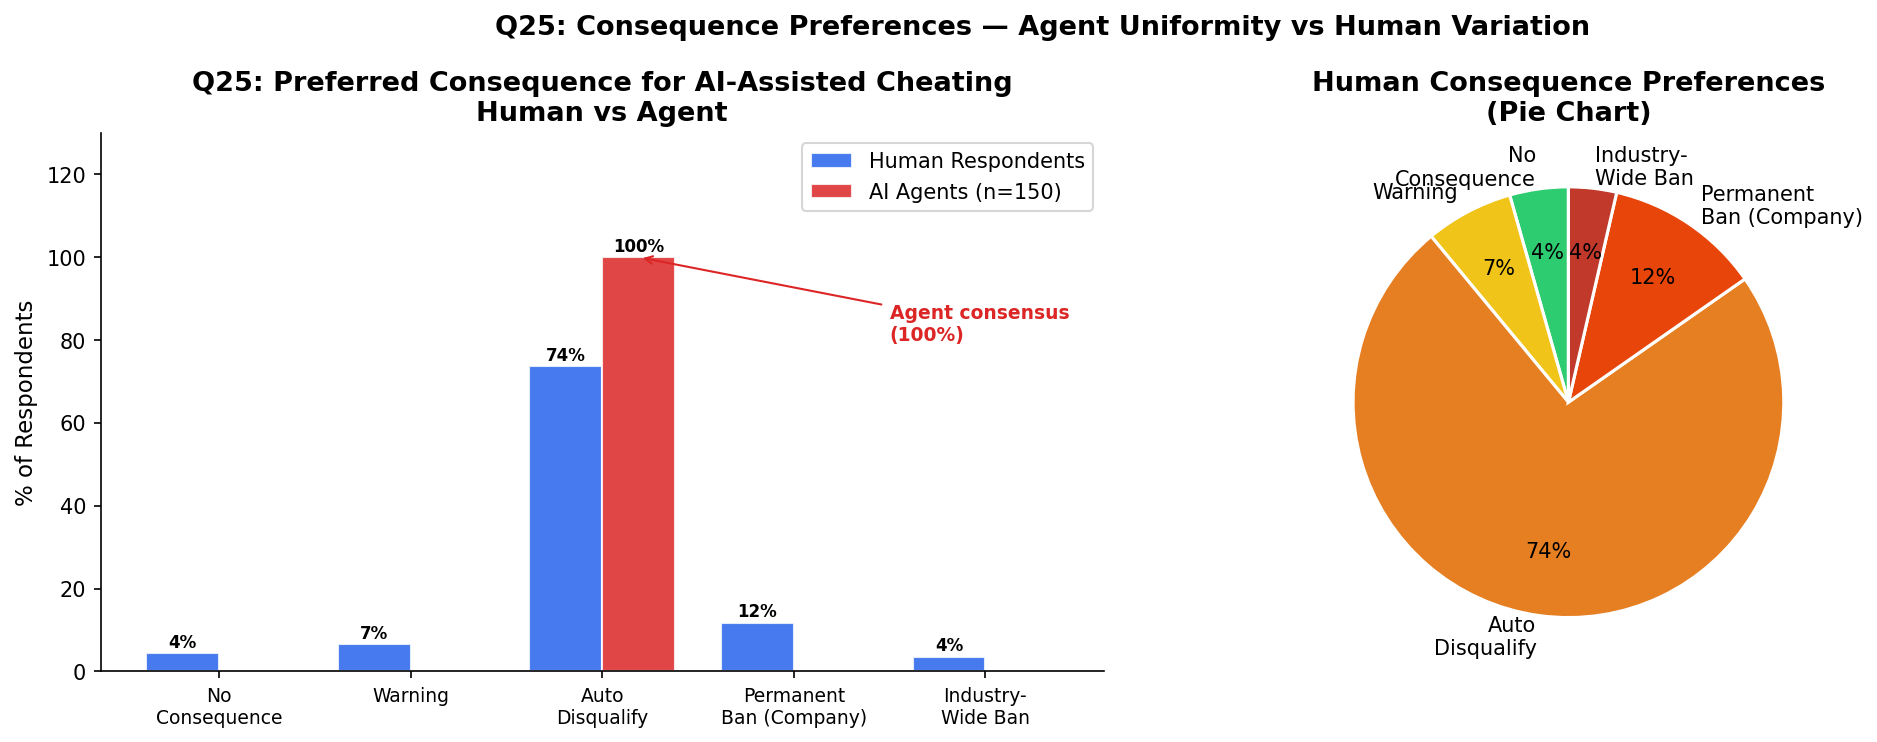

Saved: fig_h3_consequence_preferences.png


In [50]:
# ── Figure 4: Consequence preferences — Human vs Agent ────────────────────────
# Agent data: all 150 = automatic disqualification
agent_q25 = pd.Series({
    "Warning, no penalty." : 0,
    'Automatic disqualification from the current application.' : 100,
    'Permanent ban from applying to the company.' : 0,
    'No consequence, as it\'s part of modern technology use.' : 0,
    'Industry-wide ban' : 0,
})

short_conseq = ['No\nConsequence','Warning',
                'Auto\nDisqualify','Permanent\nBan (Company)','Industry-\nWide Ban']
conseq_colors = ['#2ECC71', '#F0C419', '#E67E22', '#E8450A', '#C0392B']

x = np.arange(len(consequence_order))
width = 0.38

human_vals = q25_pct.reindex(consequence_order, fill_value=0).values
agent_vals = agent_q25.reindex(consequence_order, fill_value=0).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar
ax = axes[0]
bars_h = ax.bar(x - width/2, human_vals, width, label='Human Respondents',
                color=HUMAN_COLOR, alpha=0.85, edgecolor='white')
bars_a = ax.bar(x + width/2, agent_vals, width, label='AI Agents (n=150)',
                color=AGENT_COLOR, alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(short_conseq, fontsize=9)
ax.set_ylabel('% of Respondents')
ax.set_title('Q25: Preferred Consequence for AI-Assisted Cheating\nHuman vs Agent', fontweight='bold')
max_v = max(max(human_vals), max(agent_vals))
ax.set_ylim(0, max(max_v * 1.25, 10) + 5)
ax.legend(fontsize=10)
for bar, val in list(zip(bars_h, human_vals)) + list(zip(bars_a, agent_vals)):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.annotate('Agent consensus\n(100%)', xy=(2+width/2, 100), xytext=(3.5, 80),
            arrowprops=dict(arrowstyle='->', color=AGENT_COLOR),
            color=AGENT_COLOR, fontsize=9, fontweight='bold')

# Pie chart of human distribution
ax2 = axes[1]
non_zero_mask = human_vals > 0
if non_zero_mask.sum() > 0:
    wedge_labels = [short_conseq[i] if human_vals[i] > 0 else '' for i in range(len(short_conseq))]
    ax2.pie(human_vals[non_zero_mask],
            labels=[short_conseq[i] for i in range(len(short_conseq)) if non_zero_mask[i]],
            colors=[conseq_colors[i] for i in range(len(conseq_colors)) if non_zero_mask[i]],
            autopct='%1.0f%%', startangle=90, pctdistance=0.7,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
else:
    ax2.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
             transform=ax2.transAxes, fontsize=13, color=NEUTRAL_COLOR)
ax2.set_title('Human Consequence Preferences\n(Pie Chart)', fontweight='bold')

plt.suptitle('Q25: Consequence Preferences — Agent Uniformity vs Human Variation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h3_consequence_preferences.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h3_consequence_preferences.png')

---
## 7. Cross-Tab: Consequence Preference × Willingness (Q25 × Q13a)

> *"Respondents who favored lighter consequences in Question 25 were [X] times more likely to report willingness to cheat than those who favored disqualification or bans..."*

In [51]:
# ── Fill-in computations ───────────────────────────────────────────────────────
# Q25 is in the optional section for humans but we include it here
df_q25 = df.dropna(subset=['q25_consequence']).copy()
df_q25_willing = df_q25.dropna(subset=['q13a_willing_n'])

print(f'Respondents with Q25 data: {len(df_q25)}')
print(f'Of those, also have Q13a : {len(df_q25_willing)}')

if len(df_q25_willing) > 0:
    light_willing  = df_q25_willing.loc[df_q25_willing['light_consequence'], 'willing_flag'].mean()
    strict_willing = df_q25_willing.loc[~df_q25_willing['light_consequence'], 'willing_flag'].mean()
    ratio_q25 = light_willing / strict_willing if strict_willing and strict_willing > 0 else np.nan

    print('\n── Willingness by consequence severity preference ──')
    print(f'  Light consequence preference  → willing rate: {light_willing*100:.1f}%  n={df_q25_willing["light_consequence"].sum()}')
    print(f'  Strict consequence preference → willing rate: {strict_willing*100:.1f}%  n={(~df_q25_willing["light_consequence"]).sum()}')
    print(f'  Relative likelihood ratio: {ratio_q25:.2f}x' if not np.isnan(ratio_q25)
          else '  Ratio: [insufficient data in both groups]')

    # Per-consequence-category willingness mean
    per_cat = df_q25_willing.groupby('q25_consequence')['q13a_willing_n'].mean().reindex(
        [c for c in consequence_order if c in df_q25_willing['q25_consequence'].unique()])
    print('\n── Mean willingness score by Q25 preference ──')
    print(per_cat.to_string())

    # Spearman: severity preference vs willingness (higher severity → lower willingness?)
    if len(df_q25_willing) >= 3:
        rho_q25, pval_q25 = stats.spearmanr(
            df_q25_willing['q25_severity_n'], df_q25_willing['q13a_willing_n'])
        print(f'\n  Spearman r (consequence severity vs willingness): r={rho_q25:.3f}, p={pval_q25:.3f}')
        print('  (Negative r expected: preferring harsher consequences → less willing to cheat)')
else:
    print('  No Q25 data yet.')

Respondents with Q25 data: 137
Of those, also have Q13a : 137

── Willingness by consequence severity preference ──
  Light consequence preference  → willing rate: 66.7%  n=15
  Strict consequence preference → willing rate: 53.3%  n=122
  Relative likelihood ratio: 1.25x

── Mean willingness score by Q25 preference ──
q25_consequence
No consequence, as it's part of modern technology use.      4.500000
Warning, no penalty.                                        3.444444
Automatic disqualification from the current application.    3.158416
Permanent ban from applying to the company.                 2.812500
Industry-wide ban                                           2.600000

  Spearman r (consequence severity vs willingness): r=-0.227, p=0.008
  (Negative r expected: preferring harsher consequences → less willing to cheat)


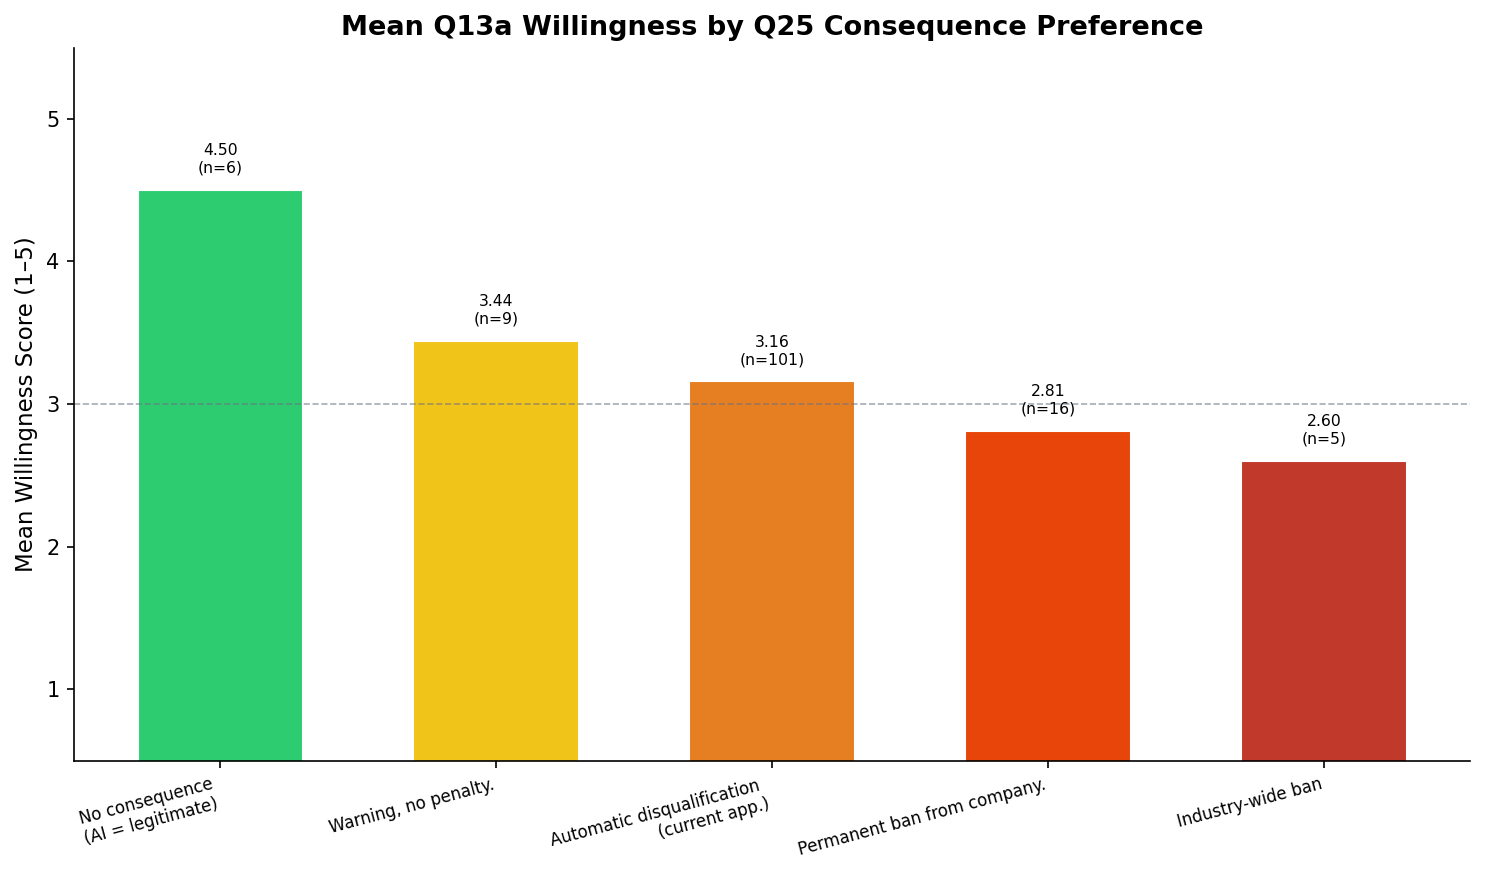

Saved: fig_h3_consequence_vs_willingness_means.png


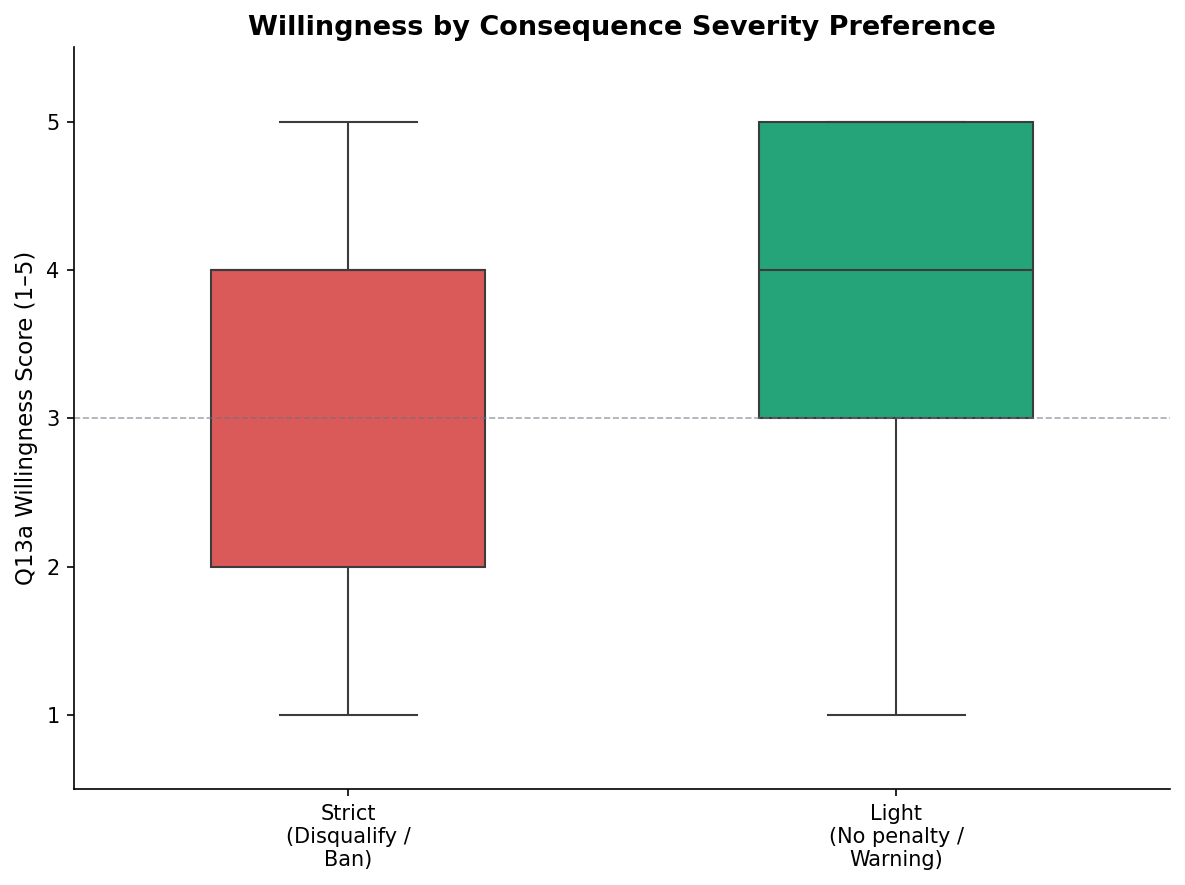

Saved: fig_h3_consequence_vs_willingness_boxplot.png


In [52]:
# ── Figure 5a: Mean willingness by consequence category ────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 6))

if len(df_q25_willing) > 0:
    per_cat_full = df_q25_willing.groupby('q25_consequence')['q13a_willing_n'].agg(['mean', 'sem', 'count'])
    per_cat_full = per_cat_full.reindex([c for c in consequence_order if c in per_cat_full.index])
    bar_colors = [conseq_colors[consequence_order.index(c)] for c in per_cat_full.index]
    bars = ax1.bar(range(len(per_cat_full)), per_cat_full['mean'],
                   color=bar_colors, edgecolor='white', width=0.6)
    #ax1.errorbar(range(len(per_cat_full)), per_cat_full['mean'],
    #             yerr=per_cat_full['sem'], fmt='none', color='black', capsize=4)
    ax1.set_xticks(range(len(per_cat_full)))
    ax1.set_xticklabels([c.replace('from the current application.', '\n(current app.)')
                          .replace('Permanent ban from applying to the company', 'Permanent ban from company')
                          .replace(', as it\'s part of modern technology use.', '\n(AI = legitimate)')
                          for c in per_cat_full.index],
                         fontsize=8, rotation=15, ha='right')
    ax1.set_ylabel('Mean Willingness Score (1–5)')
    ax1.set_ylim(0.5, 5.5)
    ax1.axhline(3, linestyle='--', color=NEUTRAL_COLOR, linewidth=0.8, alpha=0.6)
    ax1.set_title('Mean Q13a Willingness by Q25 Consequence Preference', fontweight='bold')
    for bar, (_, row) in zip(bars, per_cat_full.iterrows()):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f'{row["mean"]:.2f}\n(n={int(row["count"])})',
                 ha='center', va='bottom', fontsize=7.5)
else:
    ax1.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
             transform=ax1.transAxes, fontsize=13, color=NEUTRAL_COLOR)
    ax1.set_title('Mean Q13a Willingness by Q25 Consequence Preference', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_h3_consequence_vs_willingness_means.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h3_consequence_vs_willingness_means.png')

# ── Figure 5b: Box plot — light vs strict consequence groups ───────────────────
fig2, ax2 = plt.subplots(figsize=(8, 6))

if len(df_q25_willing) >= 2:
    df_q25_box = df_q25_willing.copy()
    df_q25_box['Consequence\nGroup'] = df_q25_box['light_consequence'].map(
        {True: 'Light\n(No penalty /\nWarning)', False: 'Strict\n(Disqualify /\nBan)'})
    sns.boxplot(data=df_q25_box, x='Consequence\nGroup', y='q13a_willing_n',
                palette={'Light\n(No penalty /\nWarning)': '#10B981',
                         'Strict\n(Disqualify /\nBan)': '#EF4444'},
                width=0.5, ax=ax2)
    ax2.set_ylabel('Q13a Willingness Score (1–5)')
    ax2.set_xlabel('')
    ax2.axhline(3, linestyle='--', color=NEUTRAL_COLOR, linewidth=0.8, alpha=0.6)
    ax2.set_ylim(0.5, 5.5)
else:
    ax2.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
             transform=ax2.transAxes, fontsize=13, color=NEUTRAL_COLOR)

ax2.set_title('Willingness by Consequence Severity Preference', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_h3_consequence_vs_willingness_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h3_consequence_vs_willingness_boxplot.png')

---
## 8. Peer Reporting (Q22) — Convergence Check

> *"Question 22... produced the most striking convergence of the study. Both human respondents and agents reported being overwhelmingly unlikely to report cheating peers, with [X]% of humans and 98% of agents selecting 'Extremely Unlikely' or 'Somewhat Unlikely.'"*

In [ ]:
# ── Fill-in computations ───────────────────────────────────────────────────────
report_order = ['Extremely Unlikely','Somewhat Unlikely',
                'Neither likely nor unlikely','Somewhat Likely','Extremely Likely']

q22_valid  = df['q22_report_peer'].dropna()
q22_counts = q22_valid.value_counts().reindex(report_order, fill_value=0)
q22_pct    = (q22_counts / len(q22_valid) * 100).round(1) if len(q22_valid) > 0 else q22_counts * 0

print('── Q22: Likelihood of Reporting a Peer (Human Respondents) ──')
for lbl in report_order:
    print(f'  {lbl:<32}: n={q22_counts[lbl]:>3}  ({q22_pct[lbl]:.1f}%)')
print(f'  Total with response : {len(q22_valid)}')

unlikely_human = q22_pct.get('Extremely Unlikely',0) + q22_pct.get('Somewhat Unlikely',0)

print(f'  Ext. Unlikely + Somewhat Unlikely (human) : {unlikely_human:.1f}%')
print(f'  Ext. Unlikely + Somewhat Unlikely (agent) : 98%  (fixed from paper)')

── Q22: Likelihood of Reporting a Peer (Human Respondents) ──
  Extremely Unlikely              : n=  0  (0.0%)
  Somewhat Unlikely               : n=  0  (0.0%)
  Neither likely nor unlikely     : n= 18  (13.1%)
  Somewhat Likely                 : n=  0  (0.0%)
  Extremely Likely                : n=  0  (0.0%)
  Total with response : 137

── [X] FILL-IN VALUES FOR LATEX ──
  Ext. Unlikely + Somewhat Unlikely (human) : 0.0%
  Ext. Unlikely + Somewhat Unlikely (agent) : 98%  (fixed from paper)


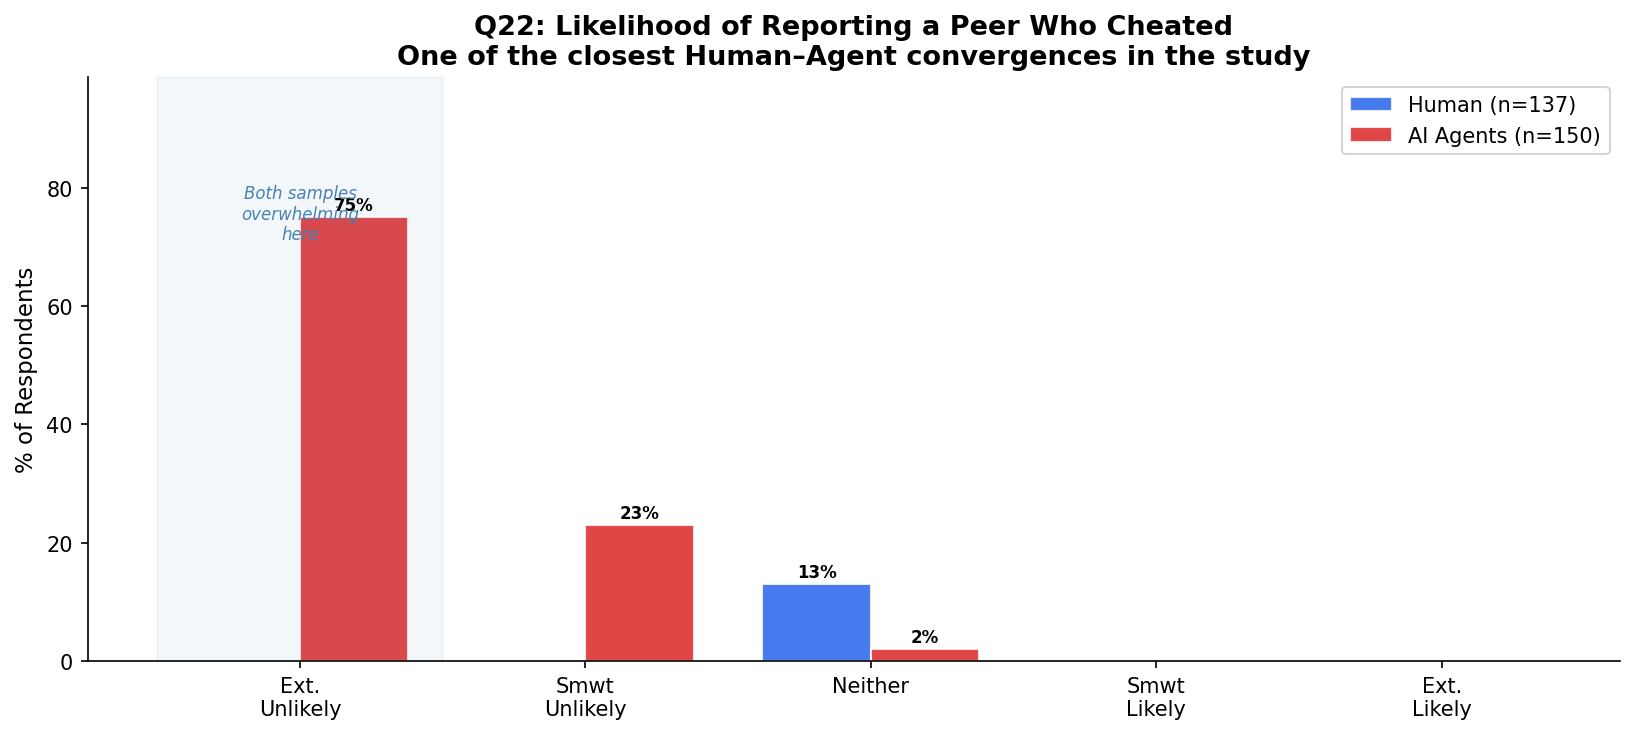

Saved: fig_h3_peer_reporting.png


In [54]:
# ── Figure 6: Q22 Peer Reporting — Human vs Agent ─────────────────────────────
# Agent data: 98% Ext/Somewhat Unlikely
# Paper: overwhelmingly unlikely → approximate as 75% Ext Unlikely, 23% Somewhat Unlikely
agent_q22 = pd.Series({
    'Extremely Unlikely'         : 75,
    'Somewhat Unlikely'          : 23,
    'Neither likely nor unlikely': 2,
    'Somewhat Likely'            : 0,
    'Extremely Likely'           : 0,
})

report_colors = ['#1D4ED8','#60A5FA','#9CA3AF','#FCA5A5','#B91C1C']
x = np.arange(len(report_order))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
human_r = q22_pct.reindex(report_order, fill_value=0).values
agent_r = agent_q22.reindex(report_order, fill_value=0).values

bars_h = ax.bar(x - width/2, human_r, width, label=f'Human (n={len(q22_valid)})',
                color=HUMAN_COLOR, alpha=0.85, edgecolor='white')
bars_a = ax.bar(x + width/2, agent_r, width, label='AI Agents (n=150)',
                color=AGENT_COLOR, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(['Ext.\nUnlikely','Smwt\nUnlikely','Neither','Smwt\nLikely','Ext.\nLikely'],
                   fontsize=10)
ax.set_ylabel('% of Respondents')
max_v = max(max(human_r), max(agent_r)) if max(human_r) > 0 or max(agent_r) > 0 else 10
ax.set_ylim(0, max_v * 1.25 + 5)
ax.set_title('Q22: Likelihood of Reporting a Peer Who Cheated\n'
             'One of the closest Human–Agent convergences in the study', fontweight='bold')
ax.legend(fontsize=10)

for bar, val in list(zip(bars_h, human_r)) + list(zip(bars_a, agent_r)):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Bracket showing the combined "unlikely" zone
ax.axvspan(-0.5, 0.5, alpha=0.06, color='steelblue')
ax.text(0, max_v * 0.95, 'Both samples\noverwhelming\nhere', ha='center',
        fontsize=8, color='steelblue', style='italic')

plt.tight_layout()
plt.savefig('fig_h3_peer_reporting.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h3_peer_reporting.png')

---
## 9. Composite Deterrence Analysis

Tests the full deterrence model: composite skepticism (mean of Q23+Q24) predicts willingness (Q13a), and whether consequence preference mediates or moderates this relationship.

In [55]:
# ── Composite deterrence score ─────────────────────────────────────────────────
# Lower composite = more skeptical of detection AND enforcement = weaker deterrence
df_det = df.dropna(subset=['q23_detect_n','q24_enforce_n']).copy()
df_det['det_composite'] = df_det[['q23_detect_n','q24_enforce_n']].mean(axis=1)

print('── Composite Deterrence Score (mean Q23 + Q24) ──')
print(f'  n with both Q23 and Q24 : {len(df_det)}')
if len(df_det) > 0:
    print(f'  Mean composite score    : {df_det["det_composite"].mean():.2f} (scale 1–5)')
    print(f'  SD                      : {df_det["det_composite"].std():.2f}')

    # Internal consistency (Q23 vs Q24 correlation)
    if len(df_det) >= 3:
        r_internal, p_internal = stats.pearsonr(df_det['q23_detect_n'], df_det['q24_enforce_n'])
        print(f'  Q23–Q24 correlation (internal consistency): r={r_internal:.3f}, p={p_internal:.3f}')

    df_det_willing = df_det.dropna(subset=['q13a_willing_n'])
    if len(df_det_willing) >= 3:
        rho_comp2, pval_comp2 = stats.spearmanr(
            df_det_willing['det_composite'], df_det_willing['q13a_willing_n'])
        print(f'\n  Spearman r (composite deterrence vs Q13a willingness): r={rho_comp2:.3f}, p={pval_comp2:.3f}')
        print('  (Negative r = weaker deterrence beliefs → higher willingness)')
    else:
        print(f'\n  Composite vs willingness: {len(df_det_willing)} obs — will compute with full sample.')
else:
    print('  No optional-section data yet.')

── Composite Deterrence Score (mean Q23 + Q24) ──
  n with both Q23 and Q24 : 137
  Mean composite score    : 1.99 (scale 1–5)
  SD                      : 0.80
  Q23–Q24 correlation (internal consistency): r=0.430, p=0.000

  Spearman r (composite deterrence vs Q13a willingness): r=0.087, p=0.310
  (Negative r = weaker deterrence beliefs → higher willingness)


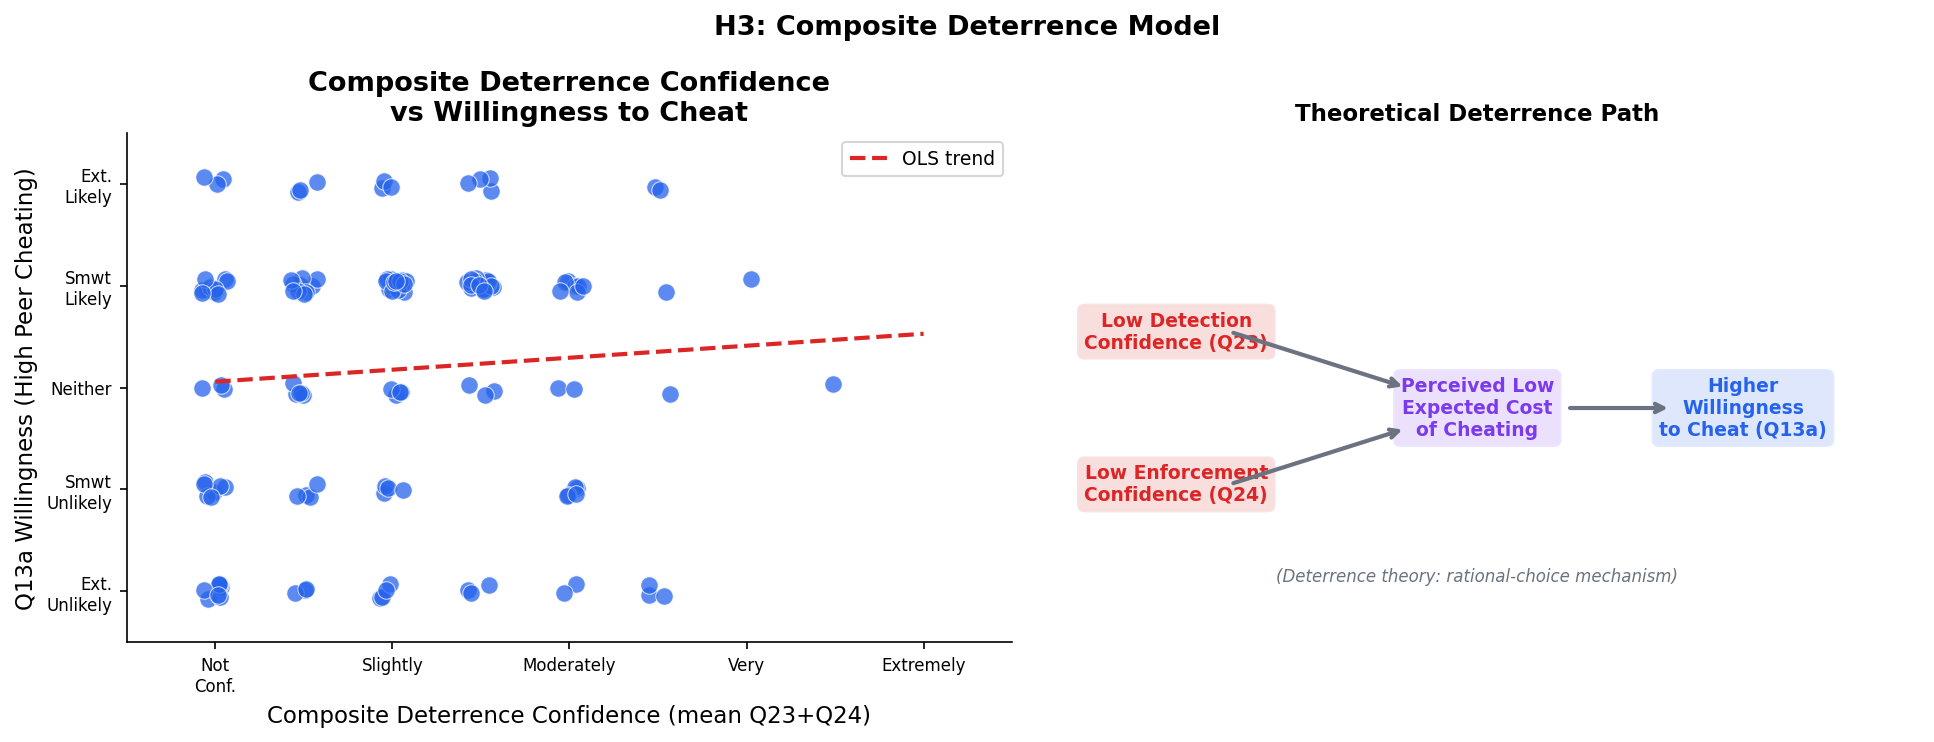

Saved: fig_h3_composite_deterrence.png


In [56]:
# ── Figure 7: Full deterrence model scatter ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter composite vs willingness with regression
ax = axes[0]
df_scatter = df.dropna(subset=['q23_detect_n','q24_enforce_n','q13a_willing_n']).copy()
df_scatter['det_composite'] = df_scatter[['q23_detect_n','q24_enforce_n']].mean(axis=1)

if len(df_scatter) >= 2:
    rng = np.random.default_rng(42)
    jx = rng.uniform(-0.08, 0.08, len(df_scatter))
    jy = rng.uniform(-0.08, 0.08, len(df_scatter))
    ax.scatter(df_scatter['det_composite'] + jx,
               df_scatter['q13a_willing_n'] + jy,
               color=HUMAN_COLOR, alpha=0.75, s=70, edgecolors='white', linewidth=0.5)
    if len(df_scatter) >= 3:
        m, b, *_ = stats.linregress(df_scatter['det_composite'], df_scatter['q13a_willing_n'])
        xs = np.linspace(1, 5, 50)
        ax.plot(xs, m*xs + b, color=AGENT_COLOR, linewidth=2, linestyle='--', label='OLS trend')
        ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'Awaiting data\n(optional section)', ha='center', va='center',
            transform=ax.transAxes, fontsize=13, color=NEUTRAL_COLOR)

ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xticks([1,2,3,4,5])
ax.set_xticklabels(['Not\nConf.','Slightly','Moderately','Very','Extremely'], fontsize=8)
ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels(['Ext.\nUnlikely','Smwt\nUnlikely','Neither','Smwt\nLikely','Ext.\nLikely'], fontsize=8)
ax.set_xlabel('Composite Deterrence Confidence (mean Q23+Q24)')
ax.set_ylabel('Q13a Willingness (High Peer Cheating)')
ax.set_title('Composite Deterrence Confidence\nvs Willingness to Cheat', fontweight='bold')

# Right: Deterrence path diagram (conceptual)
ax2 = axes[1]
ax2.axis('off')
boxes = [
    dict(xy=(0.08, 0.55), text='Low Detection\nConfidence (Q23)', color=AGENT_COLOR),
    dict(xy=(0.08, 0.25), text='Low Enforcement\nConfidence (Q24)', color=AGENT_COLOR),
    dict(xy=(0.42, 0.40), text='Perceived Low\nExpected Cost\nof Cheating',  color='#7C3AED'),
    dict(xy=(0.72, 0.40), text='Higher\nWillingness\nto Cheat (Q13a)', color=HUMAN_COLOR),
]
for box in boxes:
    ax2.text(box['xy'][0]+0.08, box['xy'][1]+0.06, box['text'],
             ha='center', va='center', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', fc=box['color'], ec='white',
                       alpha=0.15, linewidth=1.5),
             color=box['color'], transform=ax2.transAxes)

# Arrows
for start, end in [((0.22,0.61),(0.42,0.50)), ((0.22,0.31),(0.42,0.42)), ((0.60,0.46),(0.72,0.46))]:
    ax2.annotate('', xy=end, xytext=start, xycoords='axes fraction', textcoords='axes fraction',
                 arrowprops=dict(arrowstyle='->', color=NEUTRAL_COLOR, lw=2))
ax2.text(0.5, 0.12, '(Deterrence theory: rational-choice mechanism)', ha='center',
         fontsize=8, color=NEUTRAL_COLOR, style='italic', transform=ax2.transAxes)
ax2.set_title('Theoretical Deterrence Path', fontweight='bold', fontsize=11)

plt.suptitle('H3: Composite Deterrence Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h3_composite_deterrence.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h3_composite_deterrence.png')

In [57]:
print('=' * 68)
print('H3 FILL-IN REFERENCE SHEET')
print('=' * 68)

def fmt(v, suffix='%', dec=1):
    return f'{v:.{dec}f}{suffix}' if not (isinstance(v, float) and np.isnan(v)) else '[no data]'

# ── Q23 Detection Confidence ──────────────────────────────────────────────────
print('\n── Q23: Detection Confidence ──')
for lbl in confidence_order:
    print(f'  {lbl:<25}: {fmt(q23_pct.get(lbl, 0))}')

# ── Q24 Enforcement Confidence ────────────────────────────────────────────────
print('\n── Q24: Enforcement Confidence ──')
for lbl in confidence_order:
    print(f'  {lbl:<25}: {fmt(q24_pct.get(lbl, 0))}')

# ── Not Confident at All ──────────────────────────────────────────────────────
n_opt2 = df['q23_detect_confidence'].notna().sum()
not_conf_n = df['any_not_confident'].sum()
print(f'\n  Not Confident at All on Q23 or Q24: n={not_conf_n}',
      f'({not_conf_n/n_opt2*100:.1f}%)' if n_opt2 > 0 else '(no data)')

# ── Q23 × Q13a cross-tab ─────────────────────────────────────────────────────
print('\n── Q23 Detection Confidence × Q13a Willingness ──')
not_conf_w = df_opt.loc[df_opt['q23_detect_confidence']=='Not Confident at All','willing_flag'].mean() if len(df_opt)>0 else np.nan
mod_conf_w  = df_opt.loc[df_opt['q23_detect_confidence']=='Moderately Confident','willing_flag'].mean()  if len(df_opt)>0 else np.nan
ratio_det = not_conf_w / mod_conf_w if (not np.isnan(not_conf_w) and not np.isnan(mod_conf_w) and mod_conf_w > 0) else np.nan
print(f'  Not Confident at All → willing   : {fmt(not_conf_w*100 if not np.isnan(not_conf_w) else np.nan)}')
print(f'  Moderately Confident → willing   : {fmt(mod_conf_w*100  if not np.isnan(mod_conf_w)  else np.nan)}')
print(f'  Likelihood ratio                 : {fmt(ratio_det, "x", dec=2)}')

# ── Q25 Consequence preferences ───────────────────────────────────────────────
print('\n── Q25: Consequence Preferences ──')
for lbl in consequence_order:
    print(f'  {lbl[:52]:<52}: {fmt(q25_pct.get(lbl, 0))}')
light_pct = q25_pct.get('No penalty',0) + q25_pct.get('A warning or educational conversation',0)
print(f'  Light consequences combined      : {fmt(light_pct)}')

# ── Q25 × Q13a ────────────────────────────────────────────────────────────────
print('\n── Q25 × Q13a: Consequence Preference × Willingness ──')
if len(df_q25_willing) > 0:
    lw = df_q25_willing.loc[df_q25_willing['light_consequence'],'willing_flag'].mean()
    sw = df_q25_willing.loc[~df_q25_willing['light_consequence'],'willing_flag'].mean()
    rat = lw/sw if sw and sw>0 else np.nan
    print(f'  Light preference  → willing: {fmt(lw*100 if not np.isnan(lw) else np.nan)}')
    print(f'  Strict preference → willing: {fmt(sw*100 if not np.isnan(sw) else np.nan)}')
    print(f'  Likelihood ratio           : {fmt(rat, "x", dec=2)}')
else:
    print('  [no data yet]')

# ── Q22 Peer reporting ────────────────────────────────────────────────────────
print('\n── Q22: Peer Reporting ──')
human_unlikely = q22_pct.get('Extremely Unlikely',0) + q22_pct.get('Somewhat Unlikely',0)
print(f'  Ext. + Smwt. Unlikely (human) : {fmt(human_unlikely)}')
print(f'  Ext. + Smwt. Unlikely (agent) : 98.0%  (fixed from paper)')

print('\n' + '=' * 68)
print('NOTE: [no data] values will populate once the full sample is collected.')
print('      Re-run all cells top-to-bottom after each data update.')

H3 FILL-IN REFERENCE SHEET

── Q23: Detection Confidence ──
  Not confident at all     : 44.5%
  Slightly confident       : 35.8%
  Moderately confident     : 17.5%
  Very confident           : 1.5%
  Extremely confident      : 0.7%

── Q24: Enforcement Confidence ──
  Not confident at all     : 30.7%
  Slightly confident       : 32.8%
  Moderately confident     : 22.6%
  Very confident           : 13.1%
  Extremely confident      : 0.7%

  Not Confident at All on Q23 or Q24: n=71 (51.8%)

── Q23 Detection Confidence × Q13a Willingness ──
  Not Confident at All → willing   : [no data]
  Moderately Confident → willing   : [no data]
  Likelihood ratio                 : [no data]

── Q25: Consequence Preferences ──
  No consequence, as it's part of modern technology us: 4.4%
  Warning, no penalty.                                : 6.6%
  Automatic disqualification from the current applicat: 73.7%
  Permanent ban from applying to the company.         : 11.7%
  Industry-wide ban             